In [ ]:
# Install Required Libraries
!pip install datasets accelerate scikit-learn

In [ ]:
# transformers upgrade
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 49.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
# Import Libraries
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

In [ ]:
# Load Dataset
dataset_path = "/content/drive/MyDrive/00 IITR INTERNSHIP/00 Datasets/transformer_dataset_cleaned.csv"

df = pd.read_csv(dataset_path)

print(df.head())
print(df["family"].value_counts())

                                           file_name   family  \
0  51ac87b5dc1c12f3dfe43cd2114c28a845699308a2803c...  Banking   
1  1b16adaa855a73b75224d76058b72e6b39d8178a58ad08...  Banking   
2  3ef61e6781e76c13ab7d5519bc094db1dd2bfbf1ea8bf1...  Banking   
3  9bc351f77a9833e9665c478cfbcc0e93c27daa1ebd454c...  Banking   
4  21c3a37c3405a5f56b77c4ec49e9e34143754f7381a0b4...  Banking   

                                                text  
0  PERMISSION INTERNET ACCESS_NETWORK_STATE CALL_...  
1  PERMISSION SEND_SMS READ_CONTACTS READ_EXTERNA...  
2  PERMISSION INTERNET ACCESS_NETWORK_STATE CALL_...  
3  PERMISSION SEND_SMS READ_CONTACTS INTERNET CHA...  
4  PERMISSION SEND_SMS READ_CONTACTS INTERNET WRI...  
family
SMS         1089
Benign      1060
Banking      986
Adware       966
Riskware     889
Name: count, dtype: int64


In [ ]:
# Convert Labels → Numbers
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["family"])

print(label_encoder.classes_)

['Adware' 'Banking' 'Benign' 'Riskware' 'SMS']


In [ ]:
# Train Test Split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(len(train_df), len(test_df))

3992 998


In [ ]:
# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[["text","label"]])
test_dataset = Dataset.from_pandas(test_df[["text","label"]])

In [ ]:
# Load DistilBERT Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Tokenization Function
def tokenize(batch):

    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

In [ ]:
# Apply Tokenization
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])

Map:   0%|          | 0/3992 [00:00<?, ? examples/s]

Map:   0%|          | 0/998 [00:00<?, ? examples/s]

In [ ]:
# Load DistilBERT Model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Training Arguments
training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    logging_steps=50,

    report_to="none"
)

In [ ]:
# Trainer Block
# trainer = Trainer(

#     model=model,

#     args=training_args,

#     train_dataset=train_dataset,

#     eval_dataset=test_dataset
# )

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    callbacks=[]
)

In [ ]:
print(torch.cuda.is_available())
torch.cuda.get_device_name(0)

True


'Tesla T4'

In [ ]:
# Training
trainer.train()

Step,Training Loss
50,1.437637
100,0.997302
150,0.818260
200,0.597876
250,0.611061
300,0.544263
350,0.485734
400,0.423755
450,0.398785
500,0.375248


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1497, training_loss=0.3784418090152677, metrics={'train_runtime': 630.648, 'train_samples_per_second': 18.99, 'train_steps_per_second': 2.374, 'total_flos': 1586514441461760.0, 'train_loss': 0.3784418090152677, 'epoch': 3.0})

In [ ]:
# Evaluate
# trainer.evaluate()

In [ ]:
# metrics = trainer.evaluate(eval_dataset=test_dataset)

# print(metrics)

In [ ]:
# Manual Evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(axis=1)
labels = predictions.label_ids

accuracy = accuracy_score(labels, preds)

precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.93687374749499
Precision: 0.9370521454964964
Recall: 0.93687374749499
F1 Score: 0.9367374941623815


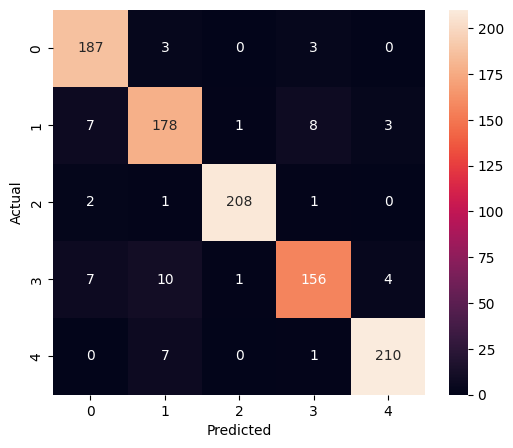

In [ ]:
# Confusion Matrix (Important for malware classification)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()